# [실습] 군집화 · 차원축소

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

# 🧭 [실습] 군집화와 차원축소 — 정답 없이 구조를 찾는다

## — 구매 정답을 군집 입력에서 제외하고 방문 세션 패턴을 탐색합니다

순서 1~5에서는 `Revenue`를 타깃으로 예측·평가·피처·Pipeline을 다뤘습니다. 오늘은 이 열을 **군집 입력에서 제외한 채** 방문 세션의 행동 패턴을 탐색하고, 그 결과를 디지털 마케팅·사이트 개선 가설로 번역합니다.

> 🤖 **오늘의 AI 활용 규칙 — 협업 단계**  
> 코드 작성은 AI와 협업할 수 있습니다. 세그먼트 이름과 액션 가설은 프로파일 수치와 한계를 근거로 학습자가 결정합니다. AI 사용 내역에는 요청·수정·검증을 기록합니다.

## 📋 오늘의 과제

디지털 분석팀이 다음을 묻습니다.

> 🧑‍💼 "방문 세션을 행동 패턴별로 나눠 사이트 경험과 캠페인 가설을 다르게 설계할 수 있을까요? 그 패턴을 구매 예측 모델에도 활용할 수 있을까요?"

| 문제 | 내용 | 확인하는 힘 |
| --- | --- | --- |
| 1 | Elbow와 Silhouette으로 `k` 후보를 좁힘 | 지표와 운영 제약의 조율 |
| 2 | 군집화·프로파일·PCA 2D | 투영 그림과 원본 프로파일 구분 |
| 3 | 세그먼트 카드 — 패턴·근거·액션 가설 | 번호를 업무 언어로 번역 |
| 4 | 군집 중심거리 피처를 예측에 재투입 | 같은 표현으로 공정하게 비교 |
| 5 | 모델 카드 v6 완성 | 정답 없는 결과와 한계 보고 |

> ⚠️ **오늘의 규율**  
> 군집 입력에는 `Revenue`를 넣지 않습니다. 군집화 뒤에 그룹별 구매율을 외부 지표로 비교할 수 있지만, 같은 데이터에서 확인한 연관성을 액션의 인과 효과로 해석하지 않습니다. `PageValues`도 거래 완료와 관련해 계산되는 지표이므로 실제 운영에서는 값이 확정되는 시점을 먼저 감사합니다.

# ⚙️ 데이터 준비

순서 1~5에서 사용한 UCI **Online Shoppers Purchasing Intention** 데이터를 다시 사용합니다. 이번 목적은 고객 분류가 아니라 **방문 세션 패턴의 회고적 탐색**입니다.

| 항목 | 내용 |
| --- | --- |
| 관측 단위 | 온라인 쇼핑 방문 세션 1건 |
| 크기 | 12,330행 · 입력 피처 17개 + 타깃 `Revenue` 1개 |
| 클래스 분포 | 구매 1,908건(15.5%) · 비구매 10,422건(84.5%) |
| 결측치 | 없음 |
| 이번 군집 입력 | 행동 수치 피처 7개 · `Revenue` 제외 |
| 출처·이용 조건 | UCI DOI `10.24432/C5F88Q` · CC BY 4.0 |

이 데이터는 세션 단위이며 고객 식별자·반복 방문 이력이 없습니다. 따라서 결과는 **고객 페르소나가 아니라 세션 행동 유형**으로 해석합니다. 실제 개인화 캠페인에는 고객 단위 집계와 동의·식별 기준이 추가로 필요합니다.

### 군집 피처 선택

- 페이지 수: `Administrative`, `Informational`, `ProductRelated`
- 체류: `ProductRelated_Duration`
- 이탈 성향: `BounceRates`, `ExitRates`
- 거래 관련: `PageValues`

`Month`·`Region` 같은 범주형 맥락은 단순 유클리드 거리에 바로 넣지 않았습니다. 행동과 무관해서가 아니라, 적절한 인코딩·거리·가중치 설계가 별도로 필요하기 때문입니다. 일부 체류 피처를 제외한 것도 학습 예제를 단순화한 선택이며 유일한 정답이 아닙니다.

> ⚠️ **`PageValues` 시점 감사**  
> UCI 설명상 `PageValues`는 전자상거래 거래 완료와 관련해 계산됩니다. 이 노트북은 완료된 세션을 회고적으로 탐색하므로 포함하지만, 세션 중 실시간 개입이나 구매 예측에 쓰려면 요청 시점에 값이 확정되어 있는지 확인합니다. 이 피처 때문에 군집별 구매율 차이가 크게 나타날 수 있습니다.

선택한 수치 피처는 단위가 크게 다르므로, 이번 목적에서는 `StandardScaler`로 같은 가중치를 부여합니다.

▶️ **코드 실행하기 · 코드 셀 1 [C1]**

In [1]:
# ─────────────────────────────────────────────
# [C1] ⚙️ 데이터 준비
# 최초 1회 다운로드 → data/ 폴더에 저장 (이후 오프라인)
# ─────────────────────────────────────────────
import urllib.request, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

def fetch_uci(url, zip_name, member):
    """UCI 정적 저장소의 zip을 내려받아 data/에 풀고, CSV 경로를 돌려줍니다."""
    csv_path = DATA_DIR / member
    if not csv_path.exists():
        zip_path = DATA_DIR / zip_name
        if not zip_path.exists():
            print(f"내려받는 중… {zip_name}")
            urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path) as z:
            z.extract(member, DATA_DIR)
    return csv_path

shoppers = pd.read_csv(fetch_uci(
    "https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip",
    "online_shoppers.zip", "online_shoppers_intention.csv"))

NUM_COLS = ["Administrative", "Administrative_Duration", "Informational",
            "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
            "BounceRates", "ExitRates", "PageValues", "SpecialDay"]
CAT_COLS = ["Month", "OperatingSystems", "Browser", "Region",
            "TrafficType", "VisitorType", "Weekend"]

# 군집화에 쓸 '행동' 피처 7개 — Revenue는 절대 포함하지 않습니다
CLUSTER_COLS = ["Administrative", "Informational", "ProductRelated",
                "ProductRelated_Duration", "BounceRates", "ExitRates", "PageValues"]

y = shoppers["Revenue"].astype(int)

print(f"세션 {len(shoppers):,}건 · 군집용 피처 {len(CLUSTER_COLS)}개")
print("\n→ 준비 완료. 이제 여러분 차례입니다.")

내려받는 중… online_shoppers.zip
세션 12,330건 · 군집용 피처 7개

→ 준비 완료. 이제 여러분 차례입니다.


# 문제 1. Elbow와 Silhouette으로 `k` 후보를 좁힌다

군집 수 `k`는 하나의 지표가 자동으로 확정하지 않습니다. 두 잣대로 후보를 좁히고 안정성·군집 크기·업무 목적을 함께 검토합니다.

```
[문제 1]
1) 군집용 7개 열을 `StandardScaler`로 표준화합니다.
2) `k=2~8`에서 K-Means를 학습하고 inertia와 Silhouette을 표로 만듭니다.
   Silhouette은 계산량을 줄이기 위해 `sample_size=5000`을 사용합니다.
3) 두 값을 각각 선 그래프로 그립니다.
4) Silhouette 최댓값과 지표상 후보 범위를 기록합니다.
```

> 🤔 **예상하기**  
> Elbow와 Silhouette이 같은 `k`를 가리킬지 예상합니다. 값이 비슷한 후보가 여러 개라면 무엇을 더 확인해야 할까요?

▶️ **코드 실행하기 · 코드 셀 2 [C2]**

 k    inertia  silhouette
 2 65249.9174      0.5112
 3 48276.3097      0.5078
 4 40866.2207      0.5015
 5 34577.4223      0.4341
 6 30421.0241      0.3885
 7 27540.3230      0.3754
 8 25016.5785      0.3189


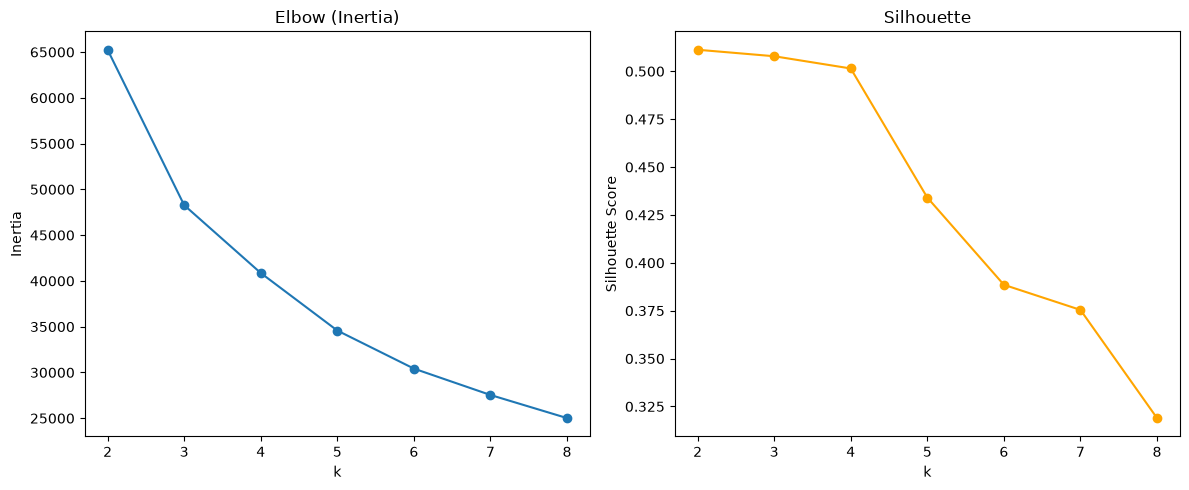


실루엣 최댓값: k=2, score=0.5112


In [2]:
# [C2] 문제 1. Elbow와 Silhouette으로 `k` 후보를 좁힌다
# ⌨️ 문제 1 — k=2~8에서 inertia와 실루엣 재기
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 여기에 코드를 작성하세요 (표준화 → k별 inertia·실루엣 → 표 → 두 그래프)
# 1) 표준화
X_scaled = StandardScaler().fit_transform(shoppers[CLUSTER_COLS])

# 2) K-Means 학습, k별 inertia·실루엣
results = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km.fit(X_scaled)
    sil = silhouette_score(X_scaled, km.labels_, sample_size=5000, random_state=RANDOM_STATE)
    results.append({"k": k, "inertia": km.inertia_, "silhouette": sil})

result_df = pd.DataFrame(results)
print(result_df.round(4).to_string(index=False))

# 3) 선 그래프 (두 지표는 스케일이 다르므로 따로)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(result_df["k"], result_df["inertia"], marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow (Inertia)")

axes[1].plot(result_df["k"], result_df["silhouette"], marker="o", color="orange")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette")

plt.tight_layout()
plt.show()

# 4) 실루엣 최댓값과 후보 k
best_row = result_df.loc[result_df["silhouette"].idxmax()]
print(f"\n실루엣 최댓값: k={int(best_row['k'])}, score={best_row['silhouette']:.4f}")

<details>
<summary>(클릭) 💡 힌트</summary>

- `X_scaled = StandardScaler().fit_transform(shoppers[CLUSTER_COLS])`
- `KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)` — `n_init`을 주지 않으면 초기값 운에 흔들립니다.
- inertia는 학습된 객체의 `.inertia_` 속성입니다.
- 실루엣은 `silhouette_score(X_scaled, km.labels_, sample_size=5000, random_state=RANDOM_STATE)`.
- 두 지표는 크기가 전혀 다르므로 **그래프를 따로** 그리는 게 좋습니다 — `plt.subplots(1, 2, ...)`.

</details>

> 🎯 **[C2] 확인하기**  
> 이 고정 5,000개 표본에서 Silhouette 최댓값은 `k=2`입니다. `k=3`은 0.5078, `k=4`는 0.5015로 차이가 작고 `k=5`부터 더 크게 낮아집니다. 이 결과만으로 0.0097의 차이가 안정적이라고 단정할 수는 없습니다. 다른 표본·시드에서 순위가 유지되는지 확인해야 합니다.  
> 다음 문제에서는 **운영상 비교 가치가 있는 후보 `k=4`를 잠정 선택**해 프로파일을 살펴봅니다. 이는 `k=4`가 통계적 정답이라는 뜻이 아닙니다. 군집 크기·해석 가능성·안정성을 확인한 뒤 채택 여부를 다시 판단합니다.

# 문제 2. k=4로 나누고, 프로파일과 2D 그림으로 확인한다

군집 번호 자체는 아무 의미가 없습니다. 의미는 **각 군집의 특성을 비교**해서 우리가 부여합니다.

```
[문제 2]
1) k=4로 KMeans를 학습시켜 군집 라벨을 얻습니다.
2) 군집별 프로파일 표를 만듭니다.
   → 7개 피처의 평균 + 각 군집의 규모(세션 수) + 구매율
   (구매율은 나눈 '뒤에' 보는 것이므로 규율 위반이 아닙니다)
3) PCA로 2차원으로 줄여 군집을 색으로 구분해 그립니다.
   설명 분산비도 함께 출력합니다.
```

> 🤔 **예상하기**  
> 군집화에 `Revenue`를 넣지 않았습니다. 그런데도 군집별 **구매율**이 크게 갈릴까요? 갈린다면, 그것은 무엇을 뜻할까요?

▶️ **코드 실행하기 · 코드 셀 3 [C3]**

         Administrative  Informational  ProductRelated  ProductRelated_Duration  BounceRates  ExitRates  PageValues  session_count  purchase_rate
cluster                                                                                                                                          
0                  1.78           0.25           22.70                   830.97         0.01       0.03        2.20           9233          0.109
1                  0.05           0.02            2.88                    53.41         0.17       0.18        0.00           1033          0.006
2                  7.27           2.54          111.16                  4366.44         0.01       0.02        6.50           1441          0.276
3                  2.60           0.40           29.75                  1142.27         0.00       0.01       68.94            623          0.793

설명 분산비: PC1=0.4116, PC2=0.2199, 합=0.6315


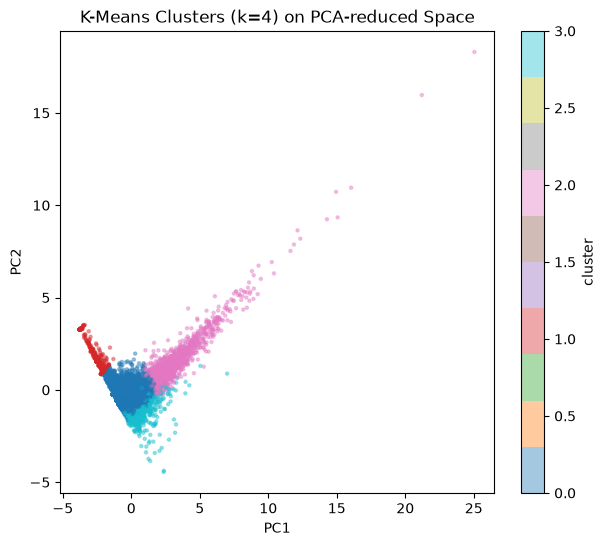

In [3]:
# [C3] 문제 2. k=4로 나누고, 프로파일과 2D 그림으로 확인한다
# ⌨️ 문제 2 — 군집화 → 프로파일 표 → PCA 2D 시각화
from sklearn.decomposition import PCA

# 여기에 코드를 작성하세요 (KMeans(k=4) → 프로파일 표 → PCA 2D 산점도)
# 1) k=4로 학습, 라벨 얻기
km4 = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE)
labels = km4.fit_predict(X_scaled)

df = shoppers.copy()
df["cluster"] = labels

# 2) 군집별 프로파일 (피처 평균 + 규모 + 구매율)
profile = df.groupby("cluster")[CLUSTER_COLS].mean().round(2)
size = df["cluster"].value_counts().sort_index()
purchase_rate = df.groupby("cluster")["Revenue"].mean().round(3)

profile["session_count"] = size
profile["purchase_rate"] = purchase_rate

print(profile.to_string())

# 3) PCA 2차원 시각화
X_pca = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)
explained = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_scaled).explained_variance_ratio_

print(f"\n설명 분산비: PC1={explained[0]:.4f}, PC2={explained[1]:.4f}, 합={explained.sum():.4f}")

plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="tab10", s=5, alpha=0.4)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters (k=4) on PCA-reduced Space")
plt.colorbar(label="cluster")
plt.show()

<details>
<summary>(클릭) 💡 힌트</summary>

- 라벨은 `KMeans(...).fit_predict(X_scaled)`로 한 번에 얻습니다.
- 프로파일은 `df.groupby("cluster")[CLUSTER_COLS].mean()`입니다.
- 규모는 `df["cluster"].value_counts().sort_index()`, 구매율은 `df.groupby("cluster")["Revenue"].mean()`.
- PCA는 **표준화된 배열**에 적용합니다: `PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)`.
- 산점도에서 군집을 색으로 나누려면 `c=labels`를 주면 됩니다. 점이 많으니 `s=5, alpha=0.4` 정도가 보기 좋습니다.

</details>

> 🎯 **[C3] 확인하기**  
> **구매율이 0.58%에서 79.29%까지, 약 137배로 갈립니다.** `Revenue`를 한 번도 보여주지 않았는데 말입니다.
>
> 군집 입력에 `Revenue`를 넣지 않았어도 행동 피처와 구매 결과가 연관되어 있어 구매율이 크게 갈립니다. 특히 `PageValues`는 거래 완료와 관련된 지표이므로 이 차이는 완전히 뜻밖의 발견이 아닙니다. 실시간 개입에 사용하려면 피처 확정 시점을 먼저 확인합니다.
>
> PCA 2D는 전체 분산의 **63.15%** 만 담습니다. 그림에서 겹쳐 보이는 점들이 실제로는 다른 군집일 수 있으니, **그림은 확인용이고 판단은 프로파일 표로** 해야 합니다.

# 문제 3. 세그먼트 카드 — 번호를 세션 패턴으로 옮긴다

`"군집 3은 Silhouette 0.50"`만으로는 업무 결정을 내릴 수 없습니다. 군집별 수치를 근거로 **세션 행동 유형과 검증할 액션 가설**을 작성합니다.

```
[문제 3]
1) 네 군집에 세션 패턴 이름을 붙입니다.
2) 각 세그먼트에 다음을 기록합니다.
   - 규모(세션 수와 전체 대비 비율)
   - 근거 지표 2~3개
   - 행동 해석 한 문장
   - 액션 가설 1개와 확인할 지표
   - 우선순위 근거
3) 세션 단위·PageValues 시점·인과 해석의 한계를 기록합니다.
```

> 🤔 **예상하기**  
> 구매율이 79.29%인 군집 3과 10.95%인 군집 0 가운데 어느 쪽을 먼저 개선해야 하는지는 구매율만으로 정할 수 있을까요? 필요한 추가 근거를 생각합니다.

▶️ **코드 실행하기 · 코드 셀 4 [C4]**

In [4]:
# [C4] 문제 3. 세그먼트 카드 — 번호를 세션 패턴으로 옮긴다
# ⌨️ 문제 3 — 세션 패턴 카드용 요약 표 만들기

# 여기에 코드를 작성하세요 (규모·비율·구매율·핵심 지표를 한 표로 정리)
total = len(shoppers)
summary = pd.DataFrame({
    "session_count": profile["session_count"],
    "비율(%)": (profile["session_count"] / total * 100).round(1),
    "purchase_rate": profile["purchase_rate"],
    "PageValues": profile["PageValues"],
    "ProductRelated": profile["ProductRelated"],
    "BounceRates": profile["BounceRates"],
    "기대_구매건수": (profile["session_count"] * profile["purchase_rate"]).round(0).astype(int),
})

print(summary.to_string())

         session_count  비율(%)  purchase_rate  PageValues  ProductRelated  BounceRates  기대_구매건수
cluster                                                                                       
0                 9233   74.9          0.109        2.20           22.70         0.01     1006
1                 1033    8.4          0.006        0.00            2.88         0.17        6
2                 1441   11.7          0.276        6.50          111.16         0.01      398
3                  623    5.1          0.793       68.94           29.75         0.00      494


In [5]:
# ProductRelated → 얼마나 많은 상품을 봤나 (탐색량)
# BounceRates → 얼마나 빨리 이탈했나 (관심도)
# PageValues → 얼마나 구매에 가까운 페이지를 봤나 (구매 임박도)

# 세그먼트 카드
## 1) 군집 0:  일반 탐색형 (대다수)
- 규모: 9,233건 (74.9%)
- 근거: ProductRelated 22.7페이지, BounceRates 매우 낮음, PageValues 2.2로 낮음
- 해석: 사이트를 정상적으로 둘러보지만, 구매 의도로 이어지는 페이지까지는 잘 안 감
- 액션 가설: 이 그룹에 PageValues 높은 상품/프로모션 페이지 노출을 늘리면 전환율이 오를 것이다 → 확인 지표: 노출 후 PageValues 평균, 구매율 변화
- 우선순위 근거: 1순위-구매율은 낮지만 규모가 워낙 커서 기대 구매건수(~1,006)가 전체 중 가장 큼 → 전환율을 아주 조금만 올려도 절대 구매건수 증가폭이 다른 어떤 세그먼트보다 큼.

## 2) 군집1: 이탈형
- 규모: 1,033건 (8.4%)
- 근거: 모든 페이지뷰 지표 거의 0, BounceRates 최고(0.17), PageValues 0
- 해석: 들어오자마자 이탈. 관심/의도 자체가 낮은 방문
- 액션 가설: 랜딩페이지 최초 노출 콘텐츠를 바꾸면 이탈률이 줄 것이다 → 확인 지표: BounceRate 변화, 재방문율
- 우선순위 근거: 4순위-구매율(0.6%)과 규모 둘 다 작아 기대 구매건수(~6)가 가장 작음 → 우선순위 낮음

## 3) 군집2: 적극 탐색형
- 규모: 1,441건 (11.7%)
- 근거: ProductRelated 111페이지로 최장, PageValues 6.5, 구매율 27.6%
- 해석: 오래 머물며 여러 상품을 비교 검토하는 "리서치형" 방문자, 구매 직전 단계로 보임
- 액션 가설: 이 그룹에 비교/리뷰 정보나 리타게팅 쿠폰을 제공하면 전환이 더 늘 것이다 → 확인 지표: 쿠폰 노출군 vs 대조군 구매율
- 우선순위 근거: 2순위-구매율·규모 모두 중간이지만 기대 구매건수(~398)가 두 번째로 큼. 이미 상품을 오래 탐색 중이라 쿠폰, 리타게팅에 반응할 가능성이 높아 개입 대비 효과가 좋을 것으로 예상

## 4) 군집3: 구매 의도 확정형
- 규모: 623건 (5.1%)
- 근거: PageValues 68.94로 압도적, BounceRates 거의 0, 구매율 79.3%
- 해석: 이미 구매 직전 단계(장바구니·결제 페이지 근처)까지 온 사람들
- 액션 가설: 결제 단계 마찰(배송비, 로그인 요구 등)을 줄이면 구매율이 더 오를 것이다 → 확인 지표: 결제 이탈률(체크아웃 단계별 이탈)
- 우선순위 근거: 3순위-구매율은 최고지만 규모가 작아 기대 구매건수(~494)는 군집 0보다 작음 → 구매율이 이미 79.3%로 매우 높아 개선 여지가 좁음. 신규 매출 증가 폭이 제한적

## 한계
- 세션 단위: 한 명의 고객이 여러 세션·여러 군집에 걸쳐 나타날 수 있어, "고객 세그먼트"가 아니라 "방문 세션 유형"으로 해석해야 함
- PageValues 시점 문제: PageValues 자체가 구글 애널리틱스에서 전환 경로를 반영해 계산되는 지표라, '높은 PageValues → 높은 구매율"은 거의 정의상 당연할 수 있음 
- 인과 해석 한계: 군집별 구매율 차이는 관찰된 연관성일 뿐, 액션(콘텐츠 변경, 쿠폰 등)을 하면 실제로 개선되는지는 A/B 테스트 같은 실험으로 검증해야 함

<details>
<summary>(클릭) 💡 힌트</summary>

- 카드 작성은 손으로 하지만, **근거 숫자는 코드로** 뽑아 두면 옮겨 적기 쉽습니다.
- 전체 대비 비율은 `규모 / len(shoppers)`입니다.
- 세그먼트별 "기대 구매 건수"도 유용합니다 — `규모 × 구매율`. 우선순위를 정할 때 구매율만 보는 것과 다른 답이 나옵니다.
- 표를 그대로 CSV로 저장해 두면 카드와 함께 제출할 수 있습니다.

</details>

> 🎯 **[C4] 확인하기**  
> 구매율·규모·관측 구매 건수는 서로 다른 우선순위를 만들지만 어느 값도 개입 효과를 직접 알려 주지 않습니다. 높은 구매율 집단에 쿠폰이 불필요한지, 긴 탐색 집단에 비교 도구가 효과적인지는 무작위 실험이나 준실험으로 확인해야 합니다.  
> 세그먼트 카드는 **관찰된 패턴 → 액션 가설 → 확인 지표**를 연결하는 문서입니다. 사람을 단정하는 페르소나가 아니라 검증 가능한 업무 가설로 작성합니다.

# 문제 4. 군집 중심거리 피처를 예측 모델에 재투입한다

`KMeans.transform()`이 만드는 각 중심까지의 거리를 예측 피처로 사용할 수 있습니다. `KMeans`도 중심을 학습하므로 교차 검증의 학습 조각에서만 `fit`해야 합니다.

```
[문제 4]
1) 세 방식을 같은 층화 5겹 CV로 평가합니다. 모델은 순서 5의 RandomForest(`min_samples_leaf=5`)입니다.
   ① 군집 파생 피처 없음
   ② `Pipeline` 안에서 표준화 → KMeans(4) 중심거리 생성(정상)
   ③ 전체 데이터로 미리 fit한 표준화·KMeans 중심거리 사용(누수)
2) F1과 AP 차이를 계산합니다.
3) 군집 파생 피처 채택 여부를 정하고 근거를 기록합니다.
4) 효과가 관찰되지 않았다면 데이터와 모델 구조로 설명합니다.
```

> 🤔 **예상하기**  
> 군집화에 쓴 7개 열은 이미 RandomForest 입력에 들어 있습니다. 같은 열을 요약한 중심거리 피처가 새 예측 정보를 제공할지 예상합니다. 누수 버전의 점수가 반드시 더 높아야 하는지도 함께 생각합니다.

▶️ **코드 실행하기 · 코드 셀 5 [C5]**

In [6]:
# [C5] 문제 4. 군집 중심거리 피처를 예측 모델에 재투입한다
# ⌨️ 문제 4 — 없음 / Pipeline 안 중심거리 / 전체-fit 중심거리 3방향 비교
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# 여기에 코드를 작성하세요 (3방향 CV → 차이 계산 → 채택 결정)
# 1)
df4 = shoppers.copy()
df4["has_page_value"] = (df4["PageValues"] > 0).astype(int)
y4 = df4["Revenue"].astype(int)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def rf():
    return RandomForestClassifier(min_samples_leaf=5, random_state=RANDOM_STATE)

scoring = {"f1": "f1", "ap": "average_precision"}

# ── 공통 전처리 조각 ──────────────────────────────
num_cat_pre = ColumnTransformer([
    ("num", StandardScaler(), NUM_COLS),
    ("flag", "passthrough", ["has_page_value"]),
    ("cat", OneHotEncoder(min_frequency=10, handle_unknown="ignore"), CAT_COLS),
])

# ① 군집 파생 피처 없음
pipe1 = Pipeline([
    ("pre", num_cat_pre),
    ("clf", rf()),
])
X1 = df4[NUM_COLS + ["has_page_value"] + CAT_COLS]

# ② Pipeline 안에서 표준화 → KMeans(4) 중심거리 생성 (정상)
cluster_branch = Pipeline([
    ("sc", StandardScaler()),
    ("km", KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE)),
])
pre_with_cluster = ColumnTransformer([
    ("num", StandardScaler(), NUM_COLS),
    ("flag", "passthrough", ["has_page_value"]),
    ("cat", OneHotEncoder(min_frequency=10, handle_unknown="ignore"), CAT_COLS),
    ("cluster_dist", cluster_branch, CLUSTER_COLS),
])
pipe2 = Pipeline([
    ("pre", pre_with_cluster),
    ("clf", rf()),
])
X2 = df4[NUM_COLS + ["has_page_value"] + CAT_COLS]

# ③ 전체 데이터로 미리 fit한 표준화·KMeans 중심거리 사용 (누수)
sc_all = StandardScaler().fit(df4[CLUSTER_COLS])
X_cluster_scaled_all = sc_all.transform(df4[CLUSTER_COLS])
km_all = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE).fit(X_cluster_scaled_all)
cluster_dist_leak = km_all.transform(X_cluster_scaled_all)  # (n, 4)

dist_cols = [f"cdist_{i}" for i in range(4)]
df4_leak = df4.copy()
for i, c in enumerate(dist_cols):
    df4_leak[c] = cluster_dist_leak[:, i]

pre_leak = ColumnTransformer([
    ("num", StandardScaler(), NUM_COLS),
    ("flag", "passthrough", ["has_page_value"]),
    ("cat", OneHotEncoder(min_frequency=10, handle_unknown="ignore"), CAT_COLS),
    ("cluster_dist", "passthrough", dist_cols),  # 이미 전체-fit으로 계산된 값
])
pipe3 = Pipeline([
    ("pre", pre_leak),
    ("clf", rf()),
])
X3 = df4_leak[NUM_COLS + ["has_page_value"] + CAT_COLS + dist_cols]

# 2) 평가
def evaluate(pipe, X, y, label):
    res = cross_validate(pipe, X, y, cv=cv5, scoring=scoring)
    print(f"{label:35s} F1={res['test_f1'].mean():.4f}  AP={res['test_ap'].mean():.4f}")
    return res

r1 = evaluate(pipe1, X1, y4, "① 군집 피처 없음")
r2 = evaluate(pipe2, X2, y4, "② Pipeline 안 중심거리 (정상)")
r3 = evaluate(pipe3, X3, y4, "③ 전체-fit 중심거리 (누수)")

print()
print(f"F1 차이 (② − ①): {r2['test_f1'].mean() - r1['test_f1'].mean():+.4f}")
print(f"AP 차이 (② − ①): {r2['test_ap'].mean() - r1['test_ap'].mean():+.4f}")
print(f"F1 차이 (③ − ②): {r3['test_f1'].mean() - r2['test_f1'].mean():+.4f}")
print(f"AP 차이 (③ − ②): {r3['test_ap'].mean() - r2['test_ap'].mean():+.4f}")

① 군집 피처 없음                          F1=0.6527  AP=0.7516
② Pipeline 안 중심거리 (정상)              F1=0.6379  AP=0.7465
③ 전체-fit 중심거리 (누수)                  F1=0.6474  AP=0.7495

F1 차이 (② − ①): -0.0149
AP 차이 (② − ①): -0.0051
F1 차이 (③ − ②): +0.0095
AP 차이 (③ − ②): +0.0031


In [7]:
# 3) 
# 군집 파생 피처를 채택하지 않는다.
# 군집 파생 피처가 있을 때 성능이 오히려 하락했다.

# 4) 
# 로지스틱 회귀는 선형모델이라 원형 구조를 못 잡아서 거리 피처가 도움이 되지만, 
# RandomForest는 애초에 비선형 모델이라 군집 중심거리라는 파생 피처가 주는 추가 정보가 거의 없다(이미 원본 피처만으로 같은 비선형 구조를 학습할 수 있음). 
# 그래서 선형모델에선 효과가 있었어도, 트리 기반 모델에선 효과가 작거나 없다.

<details>
<summary>(클릭) 💡 힌트</summary>

- `KMeans`는 **변환기로도 쓸 수 있습니다.** `ColumnTransformer`의 한 갈래에 `Pipeline([("sc", StandardScaler()), ("km", KMeans(...))])`를 넣으면, 각 군집 중심까지의 거리 `k`개가 피처로 나옵니다.
- 그 갈래에 넘길 열 목록이 `CLUSTER_COLS`입니다.
- ③은 일부러 잘못 만드는 방식입니다. 전체 데이터에 `StandardScaler.fit`과 `KMeans.fit`을 호출한 뒤, 정상 버전과 동일한 중심거리 4개를 만듭니다.
- 세 구성 모두 모델·나머지 전처리·군집 표현을 같게 둡니다. 정상은 중심거리인데 누수 버전은 군집 번호라면 공정한 비교가 아닙니다.
- 순서 5의 최종 구성은 수치 10개 + `has_page_value` + 범주 7개(`min_frequency=10`), 모델은 `min_samples_leaf=5`입니다.

</details>

> 🎯 **[C5] 확인하기**  
> 이 데이터와 RandomForest에서는 군집 중심거리 피처의 추가 이득을 확인하지 못했습니다. 군집 입력 7개가 이미 모델에 포함되어 있어 중심거리는 중복된 재표현일 수 있습니다.  
> 그렇다고 세그먼테이션 전체가 실패한 것은 아닙니다. 문제 3의 세션 유형은 사이트 개선 가설을 만드는 탐색 산출물입니다. 다만 액션 효과는 후속 실험으로 검증해야 합니다.  
> **군집화의 가치는 예측 성능과 업무 탐색에서 따로 평가**하며, 유리한 지표만 골라 결론 내리지 않습니다.

# 문제 5. 모델 카드 v6 완성 — 오늘의 제출물

v6에는 **정답 없는 결과를 보고하는 법**이 들어갑니다. 성능 숫자만으로 정당화할 수 없는 산출물이라, `k` 선택 근거와 한계 서술이 카드의 절반을 차지합니다.

```
[문제 5]
1) 세그먼트 프로파일 표를 CSV로 저장합니다 — segment_profile_v6.csv
2) 문제 3의 세그먼트 카드 4장을 아래 셀 아래에 마크다운으로 붙입니다.
3) 아래 모델 카드 v6 템플릿의 빈칸을 채웁니다.
```

▶️ **코드 실행하기 · 코드 셀 6 [C6]**

In [9]:
# [C6] 문제 5. 모델 카드 v6 완성 — 오늘의 제출물
# ⌨️ 문제 5 — 세그먼트 프로파일을 파일로 남기기

# 여기에 코드를 작성하세요 (prof/card를 CSV로 저장하고 다시 읽어 확인)
profile.to_csv("segment_profile_v6.csv", encoding="utf-8-sig")

**모델 카드 v6 템플릿** — 빈칸을 채워 이 셀에 완성합니다.

```markdown
## 모델 카드 v6 — 방문 세션 세그먼테이션

- 데이터: UCI Online Shoppers 12,330세션 · CC BY 4.0
- 군집 입력: 행동 피처 { 7 }개
  - `Revenue` 미사용 확인: { 예 }
  - `PageValues` 사용 목적·확정 시점 한계: PageValues는 구매 완료와 관련된 값이라, 완료된 세션을 분석할 때는 사용할 수 있지만 실시간 구매 예측에 사용할 경우 데이터 누수 가능성을 확인해야 한다. 따라서 PageValues 때문에 군집별 구매율 차이가 크게 나타날 수 있다.
- 스케일링: StandardScaler — KMeans는 거리 기반이라 표준화하지 않으면 단위 큰 컬럼이 거리 계산을 지배해서 다른 피처가 묻히기 때문
- `k` 후보: Silhouette k=2 { 0.5112 } / k=3 { 0.5078 } / k=4 { 0.5015 } / k=5 { 0.4341 }
  - 채택 `k={ 4 }`와 근거: K=2~4까지 Silhouette 점수 차이가 미미하기 때문에 실무 목적상 k=4를 택함. 세그먼트가 너무 많으면   
                        마케팅팀이 액션을 나누기 실무적으로 어려워지고, 너무 적으면세션 유형이 뭉뚱그려짐.
- 시각화: PCA 2D 설명 분산비 { 0.6315 }
  - 그림만으로 판단하지 않은 이유: PCA 2D는 전체 분산의 63%만 보존하므로, 그림에서 가까워/멀어 보이는 것이 원본 7차원  
                              (CLUSTER_COLS)에서의 실제 거리를 온전히 반영하지 않기 때문
- 세그먼트 카드: 세션 패턴 { 4 }장
  - 규모·구매율 범위: { 623 ~ 9,233 }세션 / { 0.6% }~{ 79.3% }
  - 액션 가설과 확인 지표  
    - 군집0(일반 탐색형): 고가치 페이지 노출 확대 → PageValues·구매율 변화로 확인
    - 군집1(이탈형): 랜딩페이지 개선 → BounceRate 변화로 확인
    - 군집2(적극 탐색형): 리타게팅 쿠폰 제공 → 쿠폰군 vs 대조군 구매율 비교로 확인
    - 군집3(구매 확정형): 결제 마찰 감소 → 체크아웃 단계별 이탈률로 확인
- 군집 중심거리 피처 검증
  - ① 없음 AP { 0.7516 } / ② Pipeline 안 { 0.7465 } / ③ 전체-fit 누수 { 0.7495 }
  - 채택 여부: 기각 — 근거: ②가 ①보다 낮고(-0.0051), 누수를 허용한 ③조차 ①을 못 넘음
  - 누수 점검: 스케일러와 KMeans가 Pipeline 안에 있는가 { 예 }
- 한계  
  - 세션 단위: "고객"이 아닌 "세션" 단위 분석이라, 한 고객이 여러 군집에 걸쳐 나타날 수 있음
  - 고객 식별자 없음: 세션을 같은 고객끼리 연결할 방법이 없어, 세션 세그먼트를 고객 생애주기나 반복 방문 패턴과 연결해 해석할 수  
    없음
  - PageValues 시점: 이미 전환 결과를 반영해 계산된 지표라, "PageValues 높음 → 구매율 높음"이 새 발견이 아니라 정의상 당연할 
    수 있음
  - 인과 효과 미검증: 세그먼트별 구매율 차이는 상관관계일 뿐이며, 액션의 실제 효과는 A/B 테스트로 검증해야 함
- AI 사용 내역
  - 무엇을 요청: 군집화·PCA·파이프라인 코드 작성 요청
  - 무엇을 수정: 컬럼 중복 에러 직접 확인 후 수정  
  - 어떻게 검증: F1·AP 수치 직접 비교해서 채택 여부 스스로 판단
```

**제출:** 노트북·`segment_profile_v6.csv`·세그먼트 카드 4장을 개인 공개 저장소의 main 브랜치에 커밋·푸시하고 저장소·커밋 링크를 제출합니다.

**스스로 점검하는 기준**

| 축 | 기준 |
| --- | --- |
| 번역 품질 | 고객을 단정하지 않고 세션 패턴과 액션 가설로 옮겼는가 |
| 근거성 | 각 해석에 프로파일 수치가 붙어 있는가 |
| 누수 점검 | 동일한 중심거리 표현으로 비교하고 `fit` 범위를 확인했는가 |
| 정직성 | PageValues 시점·세션 단위·인과 미검증·이득 없음의 한계를 적었는가 |

> 🚀 **더 나아가기**  
> `PageValues`를 군집 입력에서 제외했을 때 프로파일과 구매율 차이가 얼마나 달라지는지 비교합니다. 이 실험은 강한 거래 관련 피처가 세그먼트 해석을 얼마나 지배했는지 점검합니다.

오늘은 방문 세션을 네 가지 행동 패턴으로 탐색하고, 중심거리 피처가 예측 성능을 높이지 않은 결과도 그대로 기록했습니다.

군집은 사람의 본질을 찾아내는 답이 아니라, 선택한 피처·거리·알고리즘이 만든 탐색 결과입니다. 프로파일을 업무 가설로 번역하고 시점·누수·인과 한계를 함께 적을 때 분석이 신뢰를 얻습니다.

오늘도 한 걸음, 수고하셨습니다! 🎉  
어제의 나보다 데이터를 다루는 손이 한 뼘 더 능숙해졌습니다. 다음 시간에 또 만나요.

---

<sub>© 2026 모두의연구소(MODULABS). All rights reserved.<br>
기획·제작: 교육퍼실리테이터팀 이진영 (jy.lee@modulabs.co.kr)<br>
본 자료는 생성형 AI를 활용해 제작되었고, 제작자의 검수를 거쳐 완성되었습니다.<br>
무단 복제 및 배포를 금합니다.</sub>